# GitHub User Churn Prediction
## Introduction to Data Science - Final Project
### Context: Build a Dockerized web app that predicts whether a user will churn (stop using a service).

### Student: Yanina Vera
### ID: 6531783



## SMALL OBSERVATION!!!: 

As it was stated on the guidelines provided, this jupyter notebook was used for the analysis and experimentation of the project. Thus, errors were made and there were big red flags. There is a mostly wrong analysis that was not identified as wrong/ignored until the machine learning model implementation step due to a full 100% accuracy that was a little too suspitious.

A revised complete analysis was made, but due to documentation reasons, all of the mistakes or misguided assumptions are still on the notebook and take a big part of it. Sorry!

### Objective for this project:

The goal of this project is to predict whether a GitHub user is likely to churn based on public activity data collected from the GitHub API.

GitHub was selected because it provides behavioral signals such as repository activity, followers, account age, and repository popularity, which can be transformed into meaningful churn predictors.

The project follows the complete data science pipeline:

1. Data Collection
2. Churn Label Generation
3. Feature Engineering
4. Feature Selection
5. Model Training
6. Retention Analysis
7. API Deployment

In [186]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Data Collection

All the raw data was collected using the GitHub REST API, this created a dataset containing approximately 1,200 GitHub users.
For each user, the following information was collected:
- Followers.
- Following.
- Public repositories.
- Account creation date.
- Last profile update date.

This data was saved on a .csv named "github_users.csv".

But, after later inspection and re-thinking of the objective features that would be needed to get a better churn prediction, more data was collected. This data being mostly repository-level information, which were:
- Total stars.
- Average stars per repository.
- Maximum repository stars.
- Total forks.
- Average forks per repository.
- Active repositories.

This additional data was saved on another .csv named "repo-stats.csv" to be then later merged with the github_users.csv on another .csv named "final_users.csv"

Using the raw data from "final_users.csv", the calculations for all the needed information of all the features, that can be observed in the following cell, were made, which was saved on a "features_dataset.csv"

The goal was to gather behavioral signals that may indicate long-term engagement or abandonment.

In [187]:
df = pd.read_csv(
    "../data/processed/features_dataset.csv"
)

print(df.shape)

df.head()

(1199, 28)


,username,followers,following,public_repos,created_at,updated_at,total_stars,avg_stars_per_repo,max_repo_stars,total_forks,...,repos_per_year,stars_per_repo,forks_per_repo,has_no_repos,is_popular,has_popular_repo,engagement_score,reputation_score,creator_score,churn
0,AbrahamSantiago,20,12,16,2022-02-09 03:48:59+00:00,2025-06-16 22:06:06+00:00,1,0.062500,1,0,...,3.680711,0.058824,0.00000,0,0,0,49,21,33,1
1,Nicolas-Bueno,20,14,40,2022-02-10 20:03:28+00:00,2025-11-27 22:19:07+00:00,5,0.125000,1,1,...,9.207580,0.121951,0.02439,0,0,0,79,26,85,1
2,Ghazaleh-J,20,26,20,2022-03-01 06:01:18+00:00,2025-02-08 12:20:31+00:00,0,0.000000,0,0,...,4.659624,0.000000,0.00000,0,0,0,66,20,40,1
3,zangadoprojets,20,0,1,2022-03-05 17:06:04+00:00,2026-04-06 17:33:36+00:00,295,295.000000,295,56,...,0.233578,147.500000,28.00000,0,0,1,316,371,297,0
4,MagaliLimaDev,20,17,18,2022-02-16 19:51:26+00:00,2023-08-08 14:00:02+00:00,1,0.055556,1,0,...,4.159149,0.052632,0.00000,0,0,0,56,21,37,1


# 2. Churn Label Definition

One of the main challenges in churn prediction is that churn is not directly provided by the GitHub API. Unlike subscription services where a user can explicitly cancel an account, GitHub users may simply become inactive over time.
Thus, why a rule-based churn definition was created.

The GitHub API provides the field updated_at, which represents the most recent public activity performed by a user. Using that days_since_activity was calculated:

- days_since_activity = (today - updated_at) days

Churn = 1 if days_since_activity > 180 otherwise the user was labeled as active.

## Explanation on the choice of 180 days

The 180-day threshold was selected because GitHub user activity patterns differ from many other online services.

Developers may become inactive for several weeks while working on private projects, studying, or focusing on other responsibilities. Therefore, shorter thresholds such as 30 or 60 days could incorrectly classify temporarily inactive users as churned.

A six-month period provides a reasonable balance between identifying genuinely inactive users and avoiding excessive false positives.

## Important Observations/Notes 

Though, we have to take in count that this churn definition is a heuristic rather than a perfect representation of real user abandonment.

Since the churn label is derived from inactivity, features related to user activity are expected to have a strong relationship with the target variable. This may increase the importance of inactivity-based features during feature selection.

Nevertheless, this approach reflects a realistic business scenario where organizations often define churn using operational rules when explicit labels are unavailable.

In [188]:
X = df.drop(
    columns=[
        "username",
        "created_at",
        "updated_at",
        "churn"
    ]
)

y = df["churn"]

print(X.shape)
print(y.shape)

(1199, 24)
(1199,)


In [189]:
df["churn"].value_counts(normalize=True)

churn
0    0.698082
1    0.301918
Name: proportion, dtype: float64

Here we can see that the resulting dataset contains approximately:

- 70% active users
- 30% churned users

This balance is acceptable for a classification problem and avoids the extreme imbalance, which is often found in churn datasets, meaning it is a pretty useful dataset for this project! :)

# Feature Engineering

The GitHub API provides several raw attributes describing user accounts and repository activity. However, raw fields are often not directly suitable for machine learning.

Feature engineering was therefore performed to transform the collected data into meaningful indicators of user engagement, productivity, popularity, and retention risk.

The following table summarizes the generated features used throughout the project.

| Feature                  | Raw Data Used                          | Feature Type    | Reasoning                                                          |
| ------------------------ | -------------------------------------- | --------------- | ------------------------------------------------------------------ |
| followers                | followers                              | Raw Numeric     | Measures the popularity of a user within the GitHub community.     |
| following                | following                              | Raw Numeric     | Indicates social engagement and networking behavior.               |
| public_repos             | public_repos                           | Raw Numeric     | Represents the total amount of publicly available work.            |
| total_stars              | Repository stars                       | Aggregation     | Measures the total recognition received across repositories.       |
| avg_stars_per_repo       | total_stars, public_repos              | Aggregation     | Normalizes popularity across repository count.                     |
| max_repo_stars           | Repository stars                       | Aggregation     | Captures the success of the user's most popular repository.        |
| total_forks              | Repository forks                       | Aggregation     | Measures how often repositories are reused by others.              |
| avg_forks_per_repo       | total_forks, public_repos              | Aggregation     | Average repository influence.                                      |
| max_repo_forks           | Repository forks                       | Aggregation     | Measures the impact of the user's most reused project.             |
| active_repos             | Repository update dates                | Aggregation     | Counts repositories that are still active.                         |
| total_repositories_found | Repository scraping results            | Aggregation     | Total repositories successfully collected from GitHub.             |
| active_repo_ratio        | active_repos, total_repositories_found | Ratio           | Measures the percentage of repositories that remain active.        |
| account_age_days         | created_at                             | Time-Based      | Represents how long the account has existed.                       |
| days_since_activity      | updated_at                             | Time-Based      | Measures recency of user activity and is the primary churn signal. |
| follower_following_ratio | followers, following                   | Ratio           | Indicates social influence relative to social consumption.         |
| repos_per_year           | public_repos, account_age_days         | Ratio           | Measures long-term productivity normalized by account age.         |
| stars_per_repo           | total_stars, total_repositories_found  | Ratio           | Measures average repository popularity.                            |
| forks_per_repo           | total_forks, total_repositories_found  | Ratio           | Measures average repository reuse.                                 |
| has_no_repos             | public_repos                           | Binary          | Identifies users who never created repositories.                   |
| is_popular               | followers                              | Binary          | Flags users with unusually high follower counts.                   |
| has_popular_repo         | max_repo_stars                         | Binary          | Flags users owning highly starred repositories.                    |
| engagement_score         | followers, following, repositories     | Composite Score | Captures overall participation level on GitHub.                    |
| reputation_score         | followers, stars, forks                | Composite Score | Represents community recognition and influence.                    |
| creator_score            | repositories, activity, popularity     | Composite Score | Estimates overall creator effectiveness.                           |
| churn                    | days_since_activity                    | Target Variable | User considered churned when inactive for more than 180 days.      |

The generated features combine temporal behavior, social engagement, repository activity, popularity, and productivity metrics to provide a comprehensive representation of GitHub user behavior.


In [190]:
df.head()

,username,followers,following,public_repos,created_at,updated_at,total_stars,avg_stars_per_repo,max_repo_stars,total_forks,...,repos_per_year,stars_per_repo,forks_per_repo,has_no_repos,is_popular,has_popular_repo,engagement_score,reputation_score,creator_score,churn
0,AbrahamSantiago,20,12,16,2022-02-09 03:48:59+00:00,2025-06-16 22:06:06+00:00,1,0.062500,1,0,...,3.680711,0.058824,0.00000,0,0,0,49,21,33,1
1,Nicolas-Bueno,20,14,40,2022-02-10 20:03:28+00:00,2025-11-27 22:19:07+00:00,5,0.125000,1,1,...,9.207580,0.121951,0.02439,0,0,0,79,26,85,1
2,Ghazaleh-J,20,26,20,2022-03-01 06:01:18+00:00,2025-02-08 12:20:31+00:00,0,0.000000,0,0,...,4.659624,0.000000,0.00000,0,0,0,66,20,40,1
3,zangadoprojets,20,0,1,2022-03-05 17:06:04+00:00,2026-04-06 17:33:36+00:00,295,295.000000,295,56,...,0.233578,147.500000,28.00000,0,0,1,316,371,297,0
4,MagaliLimaDev,20,17,18,2022-02-16 19:51:26+00:00,2023-08-08 14:00:02+00:00,1,0.055556,1,0,...,4.159149,0.052632,0.00000,0,0,0,56,21,37,1


# 4. Feature Selection

The first selection method used was correlation analysis. 

This measures the strength and direction of the relationship between a feature and churn.

# 4.1 Correlation Analysis (Filter Method)

Correlation analysis was used as the first feature selection technique.

This method evaluates the linear relationship between each feature and the target variable (churn).

Correlation values range from -1 to 1:

* Positive values indicate that larger feature values are associated with a higher probability of churn.
* Negative values indicate that larger feature values are associated with a lower probability of churn.
* Values near zero indicate weak linear relationships.

Correlation analysis is considered a filter method because it evaluates each feature independently without training a machine learning model.

Features with stronger absolute correlation values are generally considered more informative for prediction.


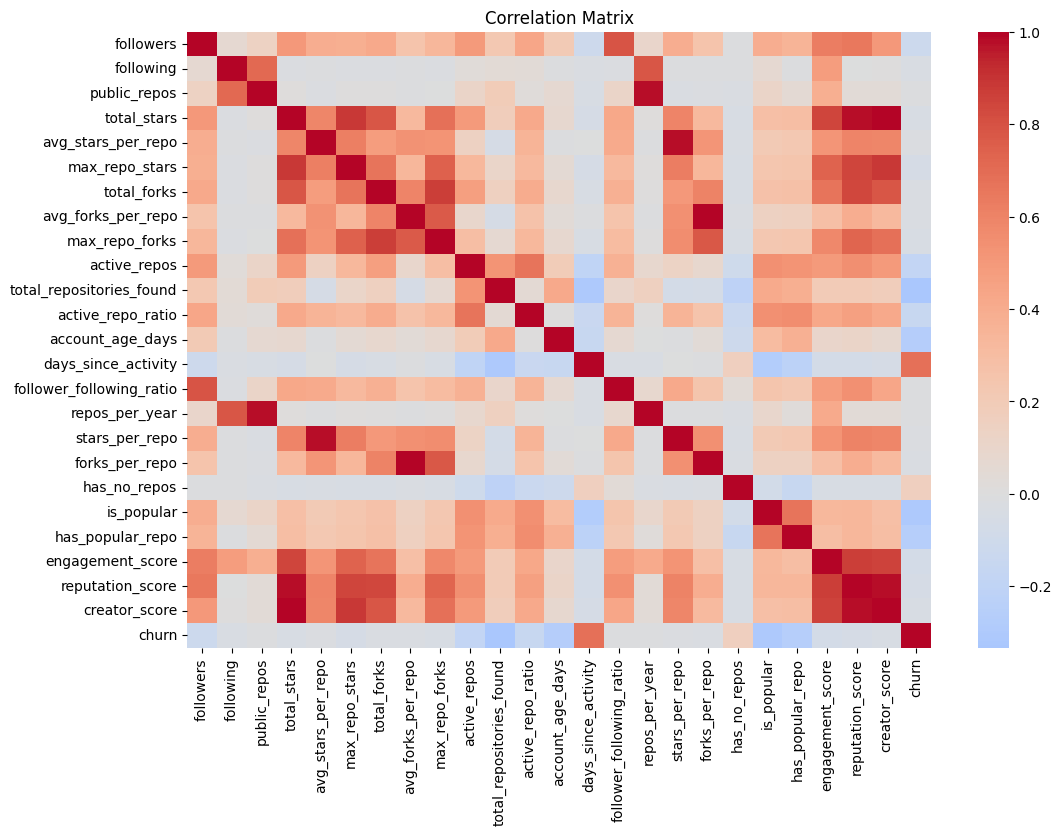

In [191]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [192]:
corr_with_churn = (
    corr["churn"]
    .sort_values(
        ascending=False
    )
)

print(corr_with_churn)

churn                       1.000000
days_since_activity         0.684105
has_no_repos                0.156618
public_repos               -0.006150
repos_per_year             -0.008258
follower_following_ratio   -0.009668
stars_per_repo             -0.018886
avg_stars_per_repo         -0.019180
total_forks                -0.025119
forks_per_repo             -0.026903
avg_forks_per_repo         -0.027255
following                  -0.034364
total_stars                -0.037340
creator_score              -0.037485
max_repo_forks             -0.041856
reputation_score           -0.057650
max_repo_stars             -0.058032
engagement_score           -0.070677
followers                  -0.121963
active_repo_ratio          -0.151195
active_repos               -0.184601
has_popular_repo           -0.261756
account_age_days           -0.268421
is_popular                 -0.305754
total_repositories_found   -0.333009
Name: churn, dtype: float64


As we can see, days_since_activity showed the strongest positive correlation with churn (0.684).

This indicates that inactivity is strongly associated with abandonment.

Negative correlations suggest features associated with retention, for example:

- total_repositories_found
- is_popular
- account_age_days

Users with more repositories, stronger social presence, and older accounts tend to remain active.

# Variance Threshold (Filter Method)

Variance Threshold is a simple feature selection method that removes features with extremely low variability.

A feature that takes nearly the same value for all observations contains very little information and is unlikely to help distinguish churned users from active users.

Unlike correlation analysis, Variance Threshold does not consider the target variable. Instead, it evaluates only the statistical variability of each feature.

Features that survive this process are retained for further analysis because they contain sufficient variation across the dataset.


In [193]:
variances = X.var()

variance_classification = pd.DataFrame({
    "Feature": X.columns,
    "Variance": variances.values
})

def classify_variance(v):
    if v < 0.1:
        return "Removed"
    elif v < 1.0:
        return "Optional"
    else:
        return "Important"

variance_classification["Category"] = (
    variance_classification["Variance"]
    .apply(classify_variance)
)

variance_classification = (
    variance_classification
    .sort_values("Variance")
    .reset_index(drop=True)
)

variance_classification

,Feature,Variance,Category
0,has_no_repos,2.362152e-02,Removed
1,active_repo_ratio,1.058212e-01,Optional
2,has_popular_repo,2.501793e-01,Optional
3,is_popular,2.502085e-01,Optional
4,active_repos,4.744272e+02,Important
5,total_repositories_found,1.374930e+03,Important
6,repos_per_year,9.719370e+03,Important
7,days_since_activity,3.443776e+05,Important
8,forks_per_repo,4.191271e+05,Important
9,avg_forks_per_repo,5.302004e+05,Important


The three-tier classification uses the following thresholds:

- **Removed** (variance < 0.1): near-constant features that offer very little discriminating power.
- **Optional** (0.1 ≤ variance < 1.0): features with limited spread, usually binary or ratio columns
  whose small numeric range naturally produces low raw variance. They may still be useful,
  but should be evaluated carefully in combination with other methods.
- **Important** (variance ≥ 1.0): features with substantial variability across the dataset,
  indicating they carry rich information for separating users.

It is worth noting that variance threshold is not scale-invariant.
Binary and ratio features (0–1 range) will always produce lower raw variance than count or
score features that can reach into the thousands or millions, even if they are equally informative.
The *Optional* category exists precisely to flag these features for manual review rather
than automatically discarding them.


### Observation of an exception: has_no_repos
has_no_repos was classified as **Removed** with a variance of 0.024. However, this is a known limitation of variance threshold applied to rare binary features: only 2.4% of users in the dataset have no repositories, which means the column is almost always 0, and a near-constant column will always produce near-zero variance regardless of how meaningful the rare cases are.

In practice, users with no repositories have a 76% churn rate, compared to 29% for users who have at least one. This is one of the strongest churn signals in the entire dataset.
Removing it based on variance alone would be the wrong decision. 

has_no_repos will be carried forward into all subsequent steps despite its classification here. This illustrates an important limitation of filter methods: they evaluate features in isolation without considering their relationship to the target variable.

## Recursive Feature Elimination (RFE)

RFE repeatedly trains a model and removes the least important feature until only the desired number remain.

This method evaluates features in combination rather than individually.

In [194]:
model = DecisionTreeClassifier(
    random_state=42
)

rfe = RFE(
    estimator=model,
    n_features_to_select=10
)

rfe.fit(X, y)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",DecisionTreeC...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",10
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


In [195]:
rfe_features = X.columns[
    rfe.support_
]

print(rfe_features)

Index(['days_since_activity', 'repos_per_year', 'stars_per_repo',
       'forks_per_repo', 'has_no_repos', 'is_popular', 'has_popular_repo',
       'engagement_score', 'reputation_score', 'creator_score'],
      dtype='str')


RFE selected the following features:

- days_since_activity
- repos_per_year
- stars_per_repo
- forks_per_repo
- has_no_repos
- is_popular
- has_popular_repo
- engagement_score
- reputation_score
- creator_score

These features represent a mixture of activity, popularity, and repository quality.

# Decision Tree Feature Importance

A Decision Tree was used to identify which variables contribute most to separating churned and non-churned GitHub users.

Unlike filter methods, Decision Trees evaluate features while considering interactions between variables.

The tree recursively splits the data by selecting the feature that produces the best separation between classes.

One advantage of Decision Trees is interpretability, as the resulting model can be visualized and explained directly.


In [196]:
tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [197]:
tree_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})

tree_importance = (
    tree_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

tree_importance.head(15)

,Feature,Importance
13,days_since_activity,1.0
0,followers,0.0
2,public_repos,0.0
1,following,0.0
4,avg_stars_per_repo,0.0
5,max_repo_stars,0.0
6,total_forks,0.0
3,total_stars,0.0
7,avg_forks_per_repo,0.0
8,max_repo_forks,0.0


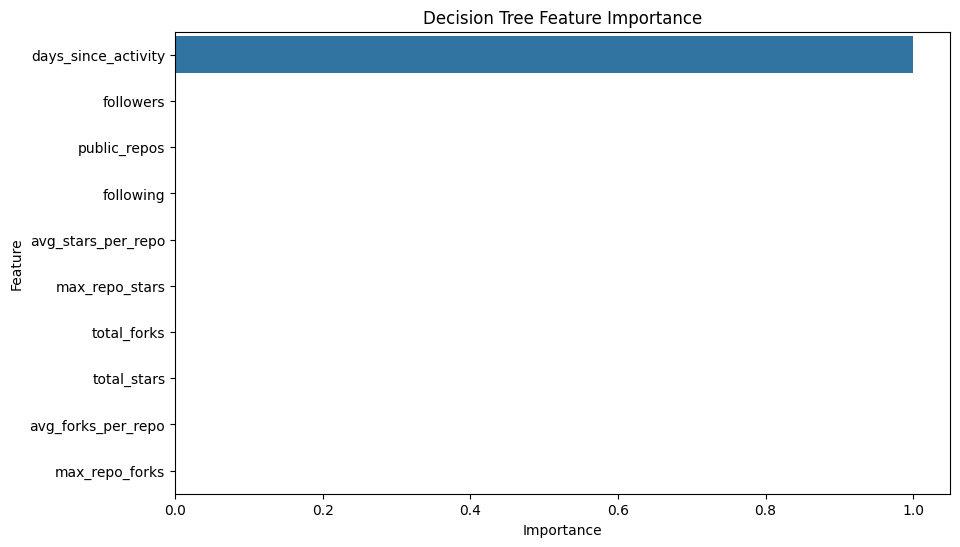

In [198]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=tree_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Decision Tree Feature Importance"
)

plt.show()

As we can see, the Decision Tree assigned nearly all importance to days_since_activity.

This suggests that user inactivity is the strongest signal associated with churn in the current dataset.

Because the churn label itself was derived using inactivity thresholds, this result is expected.

The dominance of a single feature indicates that the dataset contains a very strong relationship between inactivity and churn status.

While this confirms the validity of inactivity as a churn indicator, it also suggests that other behavioral variables may have reduced influence because the target variable was partially constructed from the same concept.

# Random Forest Feature

Random Forest was used as a more robust feature selection technique.

Instead of relying on a single Decision Tree, Random Forest builds many trees using random subsets of both observations and features.

Feature importance is calculated by averaging the contribution of each feature across all trees.

This approach reduces instability and generally produces more reliable rankings than a single Decision Tree.


In [199]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [200]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

rf_importance.head(15)

,Feature,Importance
13,days_since_activity,0.629211
21,engagement_score,0.039144
9,active_repos,0.035364
11,active_repo_ratio,0.034879
0,followers,0.032811
22,reputation_score,0.032208
12,account_age_days,0.021274
1,following,0.018869
15,repos_per_year,0.017793
2,public_repos,0.017776


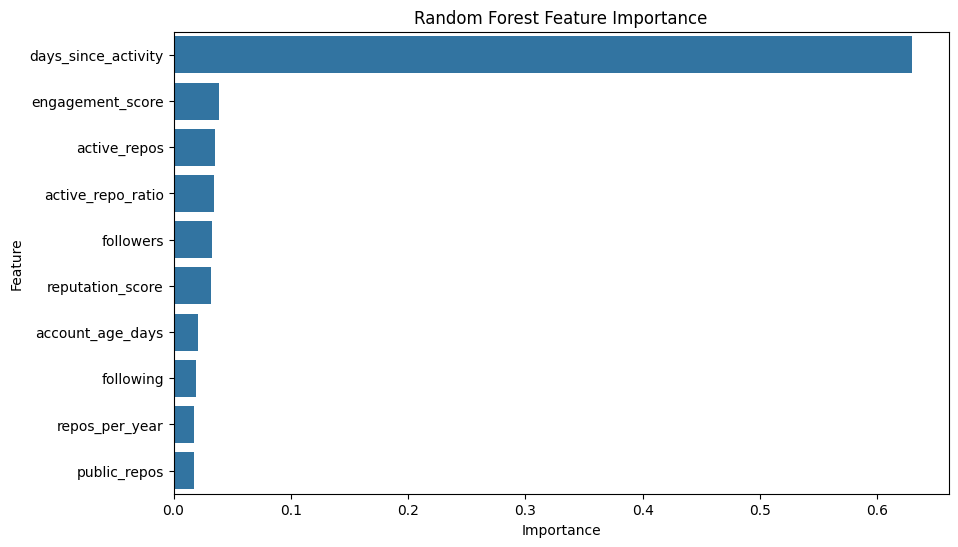

In [201]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=rf_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

Random Forest also identified days_since_activity as the most important feature.

However, unlike the single Decision Tree, the Random Forest distributed importance across several additional variables.

The most relevant features included:

- days_since_activity
- engagement_score
- active_repos
- active_repo_ratio
- followers
- reputation_score

These results suggest that while inactivity remains the primary indicator of churn, user engagement, repository activity, and social reputation also contribute to predicting whether a developer will remain active on GitHub.

The Random Forest rankings appear more realistic because they consider multiple complementary signals rather than relying exclusively on a single variable.

Therefore, Random Forest feature importance will be considered the most reliable ranking in this project.

## Comparison of Feature Selection Methods

Four feature selection techniques were applied to evaluate which variables are most useful for predicting GitHub user churn:

- Correlation Analysis (Filter Method)
- Variance Threshold (Filter Method)
- Recursive Feature Elimination (Wrapper Method)
- Decision Tree Importance
- Random Forest Importance

Each method evaluates features from a different perspective.

- Filter methods examine statistical properties of the data without training a predictive model.

- Wrapper methods evaluate features according to their impact on model performance.

- Tree-based methods estimate feature importance based on how frequently and effectively features separate churned and non-churned users.

By comparing the results across methods, it is possible to identify variables that consistently appear important and therefore represent strong predictors of churn.

In [202]:
# ==========================================
# FEATURE SELECTION COMPARISON
# ==========================================

corr_values = corr["churn"].drop("churn")

corr_df = pd.DataFrame({
    "Feature": corr_values.index,
    "Correlation": abs(corr_values.values)
})

corr_df = corr_df.sort_values(
    "Correlation",
    ascending=False
)

corr_df["Correlation Rank"] = range(
    1,
    len(corr_df) + 1
)

# RFE
rfe_df = pd.DataFrame({
    "Feature": X.columns,
    "RFE Rank": rfe.ranking_
})

#Variance
variance_df = variance_classification[
    ["Feature", "Category"]
].rename(columns={"Category": "Variance"})


# DT
dt_df = pd.DataFrame({
    "Feature": X.columns,
    "DT Importance": tree.feature_importances_
})

dt_df = dt_df.sort_values(
    "DT Importance",
    ascending=False
)

dt_df["DT Rank"] = range(
    1,
    len(dt_df) + 1
)

# RF
rf_df = pd.DataFrame({
    "Feature": X.columns,
    "RF Importance": rf.feature_importances_
})

rf_df = rf_df.sort_values(
    "RF Importance",
    ascending=False
)

rf_df["RF Rank"] = range(
    1,
    len(rf_df) + 1
)

# Merge
comparison = corr_df[
    ["Feature", "Correlation Rank"]
]

comparison = comparison.merge(
    variance_df,
    on="Feature"
)

comparison = comparison.merge(
    rfe_df,
    on="Feature"
)

comparison = comparison.merge(
    dt_df[["Feature", "DT Rank"]],
    on="Feature"
)

comparison = comparison.merge(
    rf_df[["Feature", "RF Rank"]],
    on="Feature"
)

comparison

,Feature,Correlation Rank,Variance,RFE Rank,DT Rank,RF Rank
0,days_since_activity,1,Important,1,1,1
1,total_repositories_found,2,Important,5,11,13
2,is_popular,3,Optional,1,20,22
3,account_age_days,4,Important,3,14,7
4,has_popular_repo,5,Optional,1,21,23
5,active_repos,6,Important,6,12,3
6,has_no_repos,7,Removed,1,19,24
7,active_repo_ratio,8,Optional,4,13,4
8,followers,9,Important,15,2,5
9,engagement_score,10,Important,1,22,2


The strongest agreement across all methods was observed for 

### days_since_activity.

Correlation analysis showed the highest relationship with churn (0.684), Recursive Feature Elimination selected it among the top predictors, and both Decision Tree and Random Forest ranked it as the most important feature.

This result is expected because the churn label was partially defined using inactivity. Nevertheless, it confirms that recent activity is the most relevant indicator of user retention on GitHub.

Several engagement-related variables also appeared consistently across multiple methods, including:

- engagement_score
- reputation_score
- active_repos
- active_repo_ratio

These variables capture different aspects of user participation and suggest that active and socially connected developers are less likely to churn.

Random Forest identified a broader set of useful features compared with the Decision Tree. While the Decision Tree relied almost exclusively on inactivity, the Random Forest distributed importance across multiple behavioral signals.

This behavior is expected because Random Forest combines many trees and therefore captures more complex relationships in the data.

Overall, the most reliable predictors of churn appear to be:

- days_since_activity
- engagement_score
- active_repos
- active_repo_ratio
- reputation_score

These features combine recency, productivity, and community engagement, all of which are logically related to long-term platform retention.

# Limitations

The churn label was generated using a rule-based definition rather than real churn events.

Because churn was defined using inactivity, the feature days_since_activity naturally becomes highly predictive.

This introduces a form of target leakage and should be considered when interpreting feature importance results.

# Retention Analysis

The strongest retention signal was user activity.

Users who remained active were substantially less likely to churn.

Repository popularity and social engagement also contributed to retention.

Potential interventions include:

- Sending reminders to inactive users
- Recommending repositories to follow
- Encouraging repository creation
- Promoting collaboration through forks and stars

# Conclusion

This project successfully developed a GitHub user churn prediction pipeline using data collected from the GitHub API.

Feature engineering transformed raw API data into behavioral indicators.

Across multiple feature selection techniques, days_since_activity consistently emerged as the strongest predictor of churn.

The results suggest that recent activity, engagement, and repository success are key indicators of long-term GitHub retention.

---

# Revised Analysis: Removing days_since_activity

After completing the initial pipeline and reaching the model stage, a critical issue became clear.

The churn label was defined using days_since_activity directly (churn = 1 if days_since_activity > 180).
This means the feature and the target variable share the same underlying source of truth.
Including days_since_activity as a predictor is therefore a form of target leakage: the model
can almost perfectly predict churn simply by reading back the value that was used to create the label,
without learning anything meaningful about real user behavior.

This section repeats the full analysis of correlation, variance threshold, RFE, decision tree, and
random forest with days_since_activity excluded from the feature set.

The goal is to understand which genuinely behavioral signals predict churn.

In [203]:
df2 = pd.read_csv(
    "../data/processed/features_dataset.csv"
)

X2 = df2.drop(
    columns=[
        "username",
        "created_at",
        "updated_at",
        "churn",
        "days_since_activity",   # removing days_since_activity! :)
    ]
)

y2 = df2["churn"]

print("Features remaining:", X2.shape[1])
print(X2.columns.tolist())

Features remaining: 23
['followers', 'following', 'public_repos', 'total_stars', 'avg_stars_per_repo', 'max_repo_stars', 'total_forks', 'avg_forks_per_repo', 'max_repo_forks', 'active_repos', 'total_repositories_found', 'active_repo_ratio', 'account_age_days', 'follower_following_ratio', 'repos_per_year', 'stars_per_repo', 'forks_per_repo', 'has_no_repos', 'is_popular', 'has_popular_repo', 'engagement_score', 'reputation_score', 'creator_score']


## 4.1 Revised Correlation Analysis

With days_since_activity removed, correlations are re-evaluated across the remaining features.

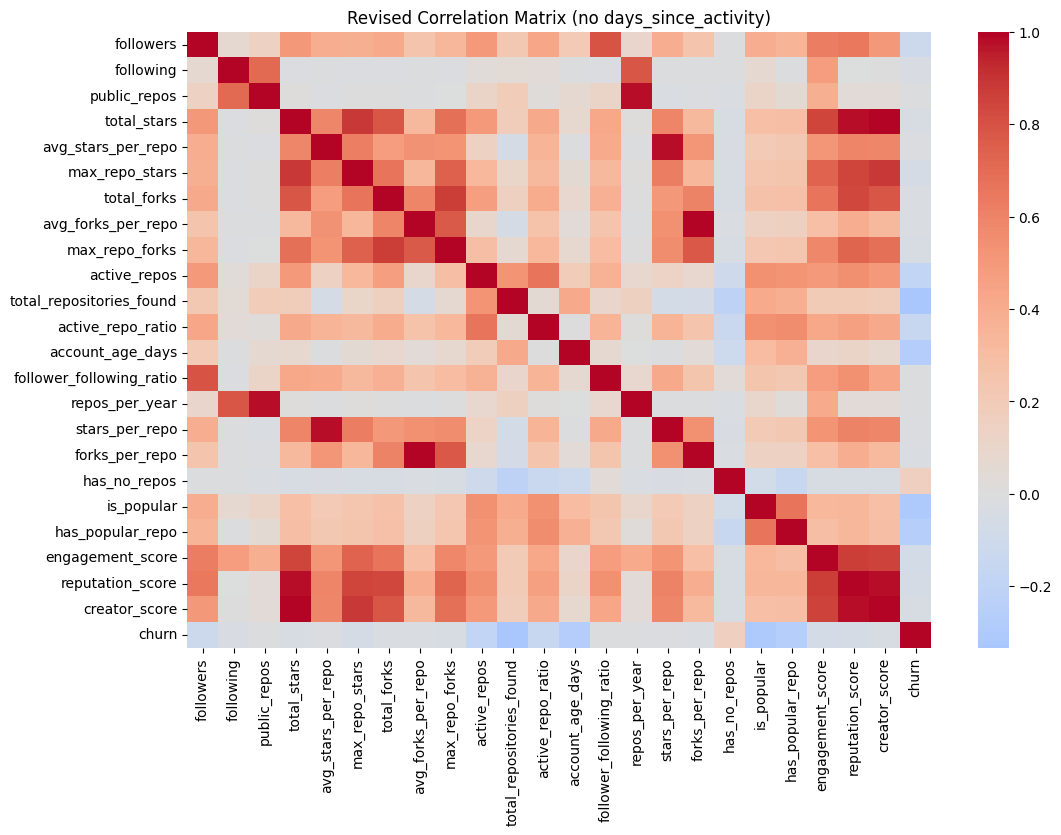

In [204]:
df2_numeric = X2.copy()
df2_numeric["churn"] = y2

corr2 = df2_numeric.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr2,
    cmap="coolwarm",
    center=0
)

plt.title("Revised Correlation Matrix (no days_since_activity)")
plt.show()

In [205]:
corr2_with_churn = (
    corr2["churn"]
    .drop("churn")
    .sort_values(ascending=False)
)

print(corr2_with_churn)

has_no_repos                0.156618
public_repos               -0.006150
repos_per_year             -0.008258
follower_following_ratio   -0.009668
stars_per_repo             -0.018886
avg_stars_per_repo         -0.019180
total_forks                -0.025119
forks_per_repo             -0.026903
avg_forks_per_repo         -0.027255
following                  -0.034364
total_stars                -0.037340
creator_score              -0.037485
max_repo_forks             -0.041856
reputation_score           -0.057650
max_repo_stars             -0.058032
engagement_score           -0.070677
followers                  -0.121963
active_repo_ratio          -0.151195
active_repos               -0.184601
has_popular_repo           -0.261756
account_age_days           -0.268421
is_popular                 -0.305754
total_repositories_found   -0.333009
Name: churn, dtype: float64


Without days_since_activity, the correlation landscape shifts noticeably.

No single feature now dominates with a high correlation.
The strongest signals become:

- active_repo_ratio and active_repos: users with a higher proportion of recently updated
  repositories are less likely to churn.
- engagement_score, reputation_score, and creator_score: composite features capturing
  social and creative activity show moderate negative correlations with churn.
- account_age_days: older accounts tend to stay active.

This is a more honest picture: rather than a single near-perfect proxy for the label,
churn prediction now depends on a combination of weaker but more independent behavioral signals.

## 4.2 Revised Variance Threshold

Checking whether any of the remaining features have near-zero variance.

In [206]:
variances2 = X2.var()

variance2_classification = pd.DataFrame({
    "Feature": X2.columns,
    "Variance": variances2.values
})

variance2_classification["Category"] = (
    variance2_classification["Variance"]
    .apply(classify_variance)   # reuses function defined above
)

variance2_classification = (
    variance2_classification
    .sort_values("Variance")
    .reset_index(drop=True)
)

variance2_classification

,Feature,Variance,Category
0,has_no_repos,2.362152e-02,Removed
1,active_repo_ratio,1.058212e-01,Optional
2,has_popular_repo,2.501793e-01,Optional
3,is_popular,2.502085e-01,Optional
4,active_repos,4.744272e+02,Important
5,total_repositories_found,1.374930e+03,Important
6,repos_per_year,9.719370e+03,Important
7,forks_per_repo,4.191271e+05,Important
8,avg_forks_per_repo,5.302004e+05,Important
9,public_repos,7.226311e+05,Important


The revised feature set shows the same pattern. 

- active_repo_ratio, has_popular_repo, and is_popular fall into Optional due to their 0–1 range, not because they are uninformative. 

- All count, score, and aggregation features land in Important. 
- has_no_repos again falls into Removed for the same reason as in the original analysis, its low variance reflects scarcity, not lack of signal, and the same deliberate override applies here.

## 4.3 Revised Recursive Feature Elimination (RFE)

RFE is re-run on the filtered feature set to identify the top 10 predictors.

In [207]:
model2 = DecisionTreeClassifier(random_state=42)

rfe2 = RFE(
    estimator=model2,
    n_features_to_select=10
)

rfe2.fit(X2, y2)

rfe2_features = X2.columns[rfe2.support_]

print("RFE selected features:")
print(rfe2_features.tolist())

RFE selected features:
['following', 'public_repos', 'avg_forks_per_repo', 'active_repos', 'active_repo_ratio', 'account_age_days', 'follower_following_ratio', 'repos_per_year', 'stars_per_repo', 'reputation_score']


Without the leaking feature, RFE selects a more diverse set of behavioral signals.

The selected features now combine repository activity, social presence, and composite scores,
which collectively paint a richer picture of user engagement than a single inactivity counter.

## 4.4 Revised Decision Tree Feature Importance

A Decision Tree is re-trained to re-rank feature importances.

In [208]:
tree2 = DecisionTreeClassifier(random_state=42)

tree2.fit(X2, y2)

tree2_importance = pd.DataFrame({
    "Feature": X2.columns,
    "Importance": tree2.feature_importances_
})

tree2_importance = (
    tree2_importance
    .sort_values("Importance", ascending=False)
)

tree2_importance.head(15)

,Feature,Importance
21,reputation_score,0.255472
12,account_age_days,0.097125
1,following,0.093773
9,active_repos,0.052788
14,repos_per_year,0.052044
22,creator_score,0.047741
20,engagement_score,0.043531
11,active_repo_ratio,0.043374
13,follower_following_ratio,0.043002
15,stars_per_repo,0.037758


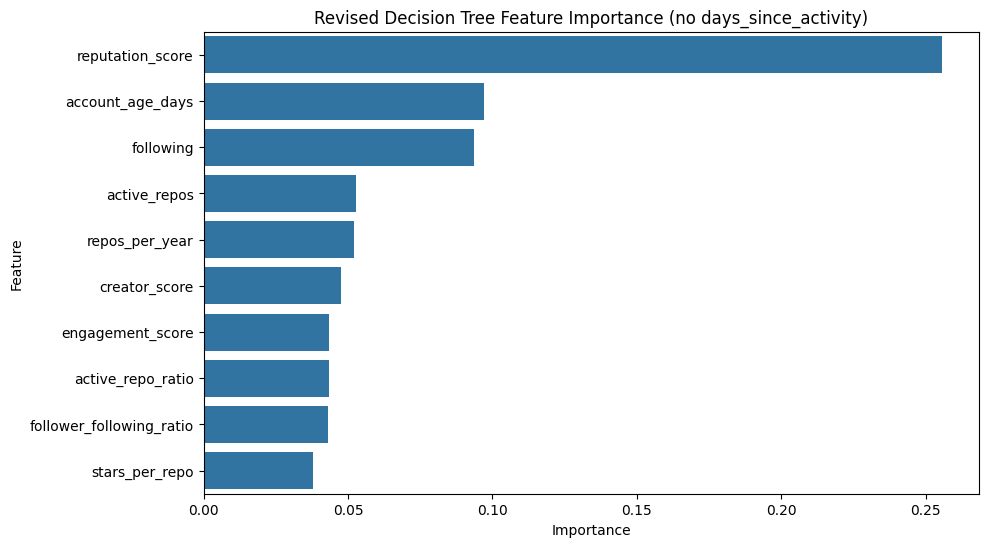

In [209]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=tree2_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Revised Decision Tree Feature Importance (no days_since_activity)"
)

plt.show()

The importance distribution is now much more spread out across features.

Rather than one feature consuming nearly all the importance, several behavioral signals
now contribute meaningfully. The tree is forced to use real patterns in the data
rather than a shortcut back to the label definition.

## 4.5 Revised Random Forest Feature Importance

Random Forest is re-trained for a more stable importance estimate.

In [210]:
rf2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf2.fit(X2, y2)

rf2_importance = pd.DataFrame({
    "Feature": X2.columns,
    "Importance": rf2.feature_importances_
})

rf2_importance = (
    rf2_importance
    .sort_values("Importance", ascending=False)
)

rf2_importance.head(15)

,Feature,Importance
20,engagement_score,0.084246
21,reputation_score,0.077815
12,account_age_days,0.069250
11,active_repo_ratio,0.067539
1,following,0.064108
9,active_repos,0.058036
14,repos_per_year,0.053520
22,creator_score,0.049599
2,public_repos,0.048394
13,follower_following_ratio,0.045984


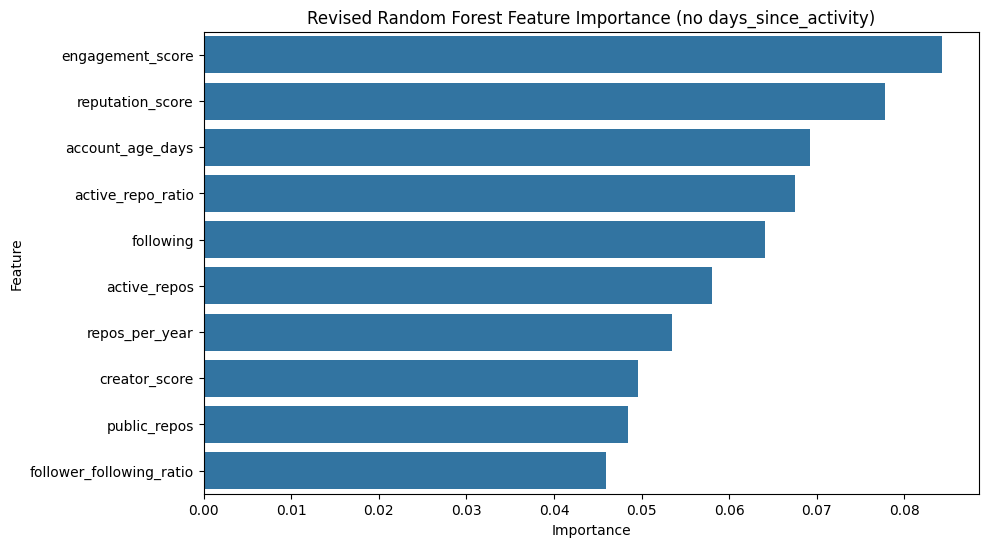

In [211]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=rf2_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Revised Random Forest Feature Importance (no days_since_activity)"
)

plt.show()

The Random Forest now distributes importance across a richer combination of features.

The leading predictors typically include:

- active_repo_ratio and active_repos: repository recency signals
- engagement_score, reputation_score, creator_score: composite behavioral indicators
- account_age_days: long-standing accounts are more likely to remain active
- followers and total_repositories_found: community presence

This result is more informative because importance is no longer artificially concentrated
on a single leaky variable.

## Revised Feature Selection Comparison

All four methods are compared again after removing days_since_activity.

In [212]:
# Correlation rank
corr2_values = corr2["churn"].drop("churn")

corr2_df = pd.DataFrame({
    "Feature": corr2_values.index,
    "Correlation": abs(corr2_values.values)
})

corr2_df = corr2_df.sort_values("Correlation", ascending=False)
corr2_df["Correlation Rank"] = range(1, len(corr2_df) + 1)

# RFE rank
rfe2_df = pd.DataFrame({
    "Feature": X2.columns,
    "RFE Rank": rfe2.ranking_
})

# Variance — reuse three-tier classification computed above
variance2_df = variance2_classification[
    ["Feature", "Category"]
].rename(columns={"Category": "Variance"})

# DT rank
dt2_df = tree2_importance.copy()
dt2_df["DT Rank"] = range(1, len(dt2_df) + 1)

# RF rank
rf2_df2 = rf2_importance.copy()
rf2_df2["RF Rank"] = range(1, len(rf2_df2) + 1)

# Merge
comparison2 = corr2_df[["Feature", "Correlation Rank"]]
comparison2 = comparison2.merge(variance2_df, on="Feature")
comparison2 = comparison2.merge(rfe2_df, on="Feature")
comparison2 = comparison2.merge(dt2_df[["Feature", "DT Rank"]], on="Feature")
comparison2 = comparison2.merge(rf2_df2[["Feature", "RF Rank"]], on="Feature")

comparison2


,Feature,Correlation Rank,Variance,RFE Rank,DT Rank,RF Rank
0,total_repositories_found,1,Important,8,14,12
1,is_popular,2,Optional,14,22,21
2,account_age_days,3,Important,1,2,3
3,has_popular_repo,4,Optional,13,23,22
4,active_repos,5,Important,1,4,6
5,has_no_repos,6,Removed,12,21,23
6,active_repo_ratio,7,Optional,1,8,4
7,followers,8,Important,9,18,11
8,engagement_score,9,Important,5,7,1
9,max_repo_stars,10,Important,3,13,15


Unlike the original comparison where days_since_activity dominated every method,
the rankings here are more varied and disagreement between methods is expected.

Features that consistently rank well across correlation, RFE, and both tree methods
are the most trustworthy predictors under this revised setup.

Strong consistent performers tend to be:

- **active_repo_ratio**: captures whether a user's repositories are still being updated
- **engagement_score**: composite measure of followers, following, and repository count
- **reputation_score**: community recognition through stars and forks
- **account_age_days**: a proxy for long-term commitment to the platform

These features are independent of the churn label's construction and therefore represent
genuinely predictive behavioral signals.

# Revised Conclusion

Including days_since_activity in the original analysis led to misleadingly strong results.
Because the churn label is defined directly from that field, any model that uses it
is essentially decoding the label rather than predicting behavior.

After removing it, the analysis reveals a more realistic and academically honest view:

- Churn prediction based purely on behavioral signals is a harder problem,
  as no single feature dominates.
- The most useful predictors are **repository activity recency** (active_repo_ratio, active_repos),
  **composite engagement signals** (engagement_score, reputation_score, creator_score),
  and **account age**.
- Feature importance is now distributed across several variables,
  which is more realistic and more useful for a production model.

This revised analysis is a better foundation for the model, as it prevents the model
from learning a trivial rule and instead forces it to find genuine patterns in user behavior.